# Milestone 3 - Portfolio Allocation and Risk Assessment Demo

This notebook demonstrates the Risk Assessment and Portfolio allocation agent layer for:
- risk assessment from scenario outputs,
- portfolio allocation under explicit constraints.



**The portfolio allocation and risk assessment layer is primarily rule-based, not a trained AI model.**

We have a **hybrid system**:
- AI for scenario generation,
- rule-based logic for risk-to-allocation decisions.


## Rule Set Implemented in Code

### A) Risk Assessment Rules (`core/risk/risk.py` -> `compute_risk`)
1. Read scenario metrics from `ScenarioEngine.run(...)` output.
2. Map configured confidence level (for example 0.95 -> `p95`) to VaR/CVaR values taken from `metrics['VaR_CVaR_horizon_return']`.
3. Set `max_drawdown_est` from `metrics['max_drawdown_summary']['mean']`.
4. Keep additional diagnostics in `tail_metrics` (`prob_profit`, summaries, drawdown stats).

### B) Portfolio Allocation Rules (`core/portfolio/portfolio.py` -> `build_portfolio`)
1. Convert user risk tolerance `rt` in [0, 100] to risk penalty:
   - `lambda = 3.0 - 2.5 * (rt / 100)`
2. For each asset compute score from scenario/risk inputs:
   - `mu = expected horizon return mean`
   - `pp = probability of profit`
   - `risk_mag = |CVaR| + 0.5 * |max_drawdown_est|`
   - `score = mu + 0.10 * (pp - 0.5) - lambda * risk_mag`
3. Rank assets by score and keep top `top_k`.
4. Convert scores to weights with softmax-like normalization.
5. Enforce constraints:
   - max weight cap,
   - optional min weight floor,
   - renormalization.
6. Optional cash bucket:
   - if `allow_cash=True`, `cash_weight = (1 - rt/100) * 0.25`.
   - lower risk tolerance means more cash.


In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

ROOT = Path.cwd().resolve()
if not (ROOT / 'core').exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

from core.risk import compute_risk, RiskConfig
from core.portfolio import build_portfolio, PortfolioConstraints
from core.pipelines.scenario_engine import ScenarioEngine, ScenarioConfig
from core.models.quantile_ml_walkforward_generator import WalkForwardMLConfig

print('Project root:', ROOT)


Project root: C:\Users\sia\Desktop\capstone\src\Agentic-Crypto-Return-Service


## Demo 1: Pure Logic Demo (Deterministic Inputs)

This demo uses synthetic scenario metric dictionaries to isolate and visualize the allocation rules.
No model training is performed.


In [2]:
# Synthetic scenario outputs (same structure as ScenarioEngine.run output)
scenario_outputs = {
    'BTC-USD': {
        'asset': 'BTC-USD',
        'summary': {'horizon_days': 14},
        'metrics': {
            'prob_profit': 0.62,
            'prob_loss': 0.38,
            'horizon_return_summary': {'mean': 0.045, 'median': 0.03, 'p05': -0.08, 'p95': 0.16},
            'VaR_CVaR_horizon_return': {'VaR': -0.09, 'CVaR': -0.14},
            'max_drawdown_summary': {'mean': -0.12, 'median': -0.10, 'p05': -0.25, 'p95': -0.03},
            'terminal_price_summary': {'mean': 1.0},
        },
    },
    'ETH-USD': {
        'asset': 'ETH-USD',
        'summary': {'horizon_days': 14},
        'metrics': {
            'prob_profit': 0.58,
            'prob_loss': 0.42,
            'horizon_return_summary': {'mean': 0.055, 'median': 0.04, 'p05': -0.10, 'p95': 0.19},
            'VaR_CVaR_horizon_return': {'VaR': -0.11, 'CVaR': -0.18},
            'max_drawdown_summary': {'mean': -0.15, 'median': -0.13, 'p05': -0.30, 'p95': -0.04},
            'terminal_price_summary': {'mean': 1.0},
        },
    },
    'SOL-USD': {
        'asset': 'SOL-USD',
        'summary': {'horizon_days': 14},
        'metrics': {
            'prob_profit': 0.54,
            'prob_loss': 0.46,
            'horizon_return_summary': {'mean': 0.085, 'median': 0.06, 'p05': -0.18, 'p95': 0.30},
            'VaR_CVaR_horizon_return': {'VaR': -0.20, 'CVaR': -0.30},
            'max_drawdown_summary': {'mean': -0.25, 'median': -0.22, 'p05': -0.45, 'p95': -0.08},
            'terminal_price_summary': {'mean': 1.0},
        },
    },
    'ADA-USD': {
        'asset': 'ADA-USD',
        'summary': {'horizon_days': 14},
        'metrics': {
            'prob_profit': 0.51,
            'prob_loss': 0.49,
            'horizon_return_summary': {'mean': 0.035, 'median': 0.02, 'p05': -0.12, 'p95': 0.18},
            'VaR_CVaR_horizon_return': {'VaR': -0.14, 'CVaR': -0.22},
            'max_drawdown_summary': {'mean': -0.18, 'median': -0.16, 'p05': -0.36, 'p95': -0.06},
            'terminal_price_summary': {'mean': 1.0},
        },
    },
}

risk_cfg = RiskConfig(confidence_levels=[0.95])
risks = {sym: compute_risk(out, risk_cfg) for sym, out in scenario_outputs.items()}

# Run allocation for multiple user risk tolerances
risk_tolerance_grid = [20, 50, 80]
portfolio_results = {}

for rt in risk_tolerance_grid:
    constraints = PortfolioConstraints(
        user_risk_tolerance=rt,
        top_k=4,
        max_weight_per_asset=0.55,
        min_weight_per_asset=0.00,
        allow_cash=True,
    )
    portfolio_results[rt] = build_portfolio(scenario_outputs, risks, constraints)

# Show details tables
for rt in risk_tolerance_grid:
    print(f'\n=== User Risk Tolerance = {rt} ===')
    pr = portfolio_results[rt]
    print('Weights:', pr.weights)
    df = pd.DataFrame([
        {
            'symbol': d.symbol,
            'weight': d.weight,
            'score': d.score,
            'expected_return_mean': d.expected_return_mean,
            'prob_profit': d.prob_profit,
            'cvar': d.cvar,
            'max_drawdown_est': d.max_drawdown_est,
        }
        for d in pr.details
    ])
    display(df.sort_values('score', ascending=False).reset_index(drop=True))



=== User Risk Tolerance = 20 ===
Weights: {'BTC-USD': 0.2493083684193294, 'ETH-USD': 0.21858841054848643, 'ADA-USD': 0.18543243013052038, 'SOL-USD': 0.14667079090166388, 'CASH': 0.2}


,symbol,weight,score,expected_return_mean,prob_profit,cvar,max_drawdown_est
0,BTC-USD,0.249308,-0.4430,0.045,0.62,-0.14,-0.12
1,ETH-USD,0.218588,-0.5745,0.055,0.58,-0.18,-0.15
2,ADA-USD,0.185432,-0.7390,0.035,0.51,-0.22,-0.18
3,SOL-USD,0.146671,-0.9735,0.085,0.54,-0.30,-0.25



=== User Risk Tolerance = 50 ===
Weights: {'BTC-USD': 0.25600429913060047, 'ETH-USD': 0.23391182727178797, 'ADA-USD': 0.20678802563057336, 'SOL-USD': 0.17829584796703832, 'CASH': 0.125}


,symbol,weight,score,expected_return_mean,prob_profit,cvar,max_drawdown_est
0,BTC-USD,0.256004,-0.29300,0.045,0.62,-0.14,-0.12
1,ETH-USD,0.233912,-0.38325,0.055,0.58,-0.18,-0.15
2,ADA-USD,0.206788,-0.50650,0.035,0.51,-0.22,-0.18
3,SOL-USD,0.178296,-0.65475,0.085,0.54,-0.30,-0.25



=== User Risk Tolerance = 80 ===
Weights: {'BTC-USD': 0.25999752910952717, 'ETH-USD': 0.24756474098632947, 'ADA-USD': 0.22807445383262998, 'SOL-USD': 0.2143632760715132, 'CASH': 0.04999999999999999}


,symbol,weight,score,expected_return_mean,prob_profit,cvar,max_drawdown_est
0,BTC-USD,0.259998,-0.143,0.045,0.62,-0.14,-0.12
1,ETH-USD,0.247565,-0.192,0.055,0.58,-0.18,-0.15
2,ADA-USD,0.228074,-0.274,0.035,0.51,-0.22,-0.18
3,SOL-USD,0.214363,-0.336,0.085,0.54,-0.30,-0.25


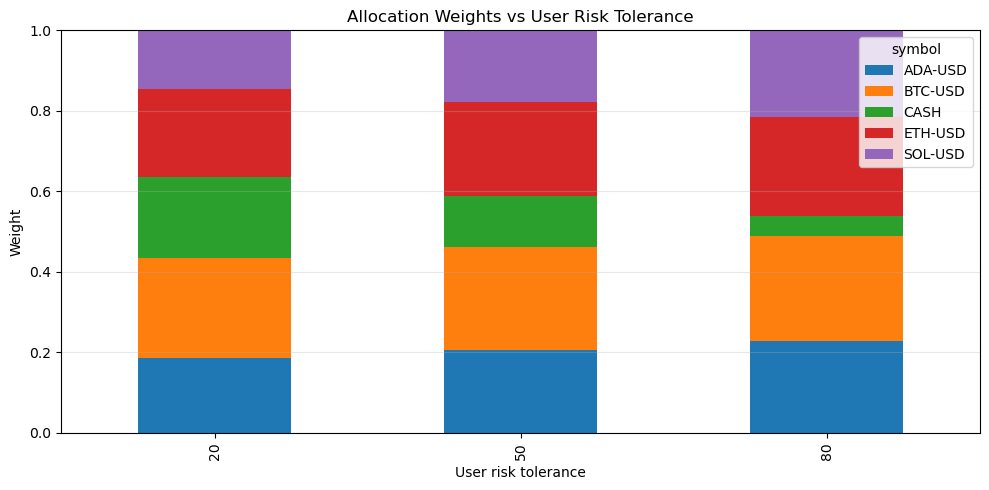

,risk_tolerance,lambda,cash_weight_rule,actual_cash_weight
0,20,2.50,0.200,0.200
1,50,1.75,0.125,0.125
2,80,1.00,0.050,0.050


In [3]:
# Visualization of rule behavior across risk tolerances
rows = []
for rt, pr in portfolio_results.items():
    for sym, w in pr.weights.items():
        rows.append({'risk_tolerance': rt, 'symbol': sym, 'weight': w})
weights_df = pd.DataFrame(rows)

pivot_w = weights_df.pivot(index='risk_tolerance', columns='symbol', values='weight').fillna(0.0)

ax = pivot_w.plot(kind='bar', stacked=True, figsize=(10, 5))
ax.set_title('Allocation Weights vs User Risk Tolerance')
ax.set_xlabel('User risk tolerance')
ax.set_ylabel('Weight')
ax.set_ylim(0, 1)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Show lambda and cash rule explicitly
rule_df = pd.DataFrame([
    {
        'risk_tolerance': rt,
        'lambda': 3.0 - (rt / 100.0) * 2.5,
        'cash_weight_rule': (1.0 - rt / 100.0) * 0.25,
        'actual_cash_weight': portfolio_results[rt].weights.get('CASH', 0.0),
    }
    for rt in risk_tolerance_grid
])

display(rule_df)


## Demo 2: End-to-End with Real Project Data (No Training)

This demo loads feature CSVs and uses the existing scenario pipeline outputs to run:
`ScenarioEngine -> compute_risk -> build_portfolio`.

No model is trained in this notebook.


In [4]:
from core.storage.coin_repository import get_coin_repository
from core.storage.market_data_repository import get_market_data_repository

coin_repo = get_coin_repository()
market_repo = get_market_data_repository()

def load_features_df(symbol: str) -> pd.DataFrame:
    df = market_repo.read_features(symbol=symbol)
    df['date'] = pd.to_datetime(df['date'], errors='coerce')
    df = df.dropna(subset=['date']).sort_values('date').reset_index(drop=True)
    if 'close' in df.columns:
        df['close'] = pd.to_numeric(df['close'], errors='coerce')
        df = df.dropna(subset=['close']).reset_index(drop=True)
    return df

selected_symbols = ['BTC', 'ETH', 'SOL']

# Detect artifacts root for quantile bundles (supports both paths)
art_root = ROOT / 'artifacts' / 'models'
if not art_root.exists():
    alt = ROOT / 'artifacts' / 'model'
    if alt.exists():
        art_root = alt

assets_data = {}
for symbol in selected_symbols:
    fdf = load_features_df(symbol)
    if fdf.empty:
        continue

    ticker = coin_repo.get_by_symbol(symbol).yahoo_ticker
    bundle_path = art_root / ticker / 'quantile_model_bundle.joblib'

    if bundle_path.exists():
        assets_data[ticker] = fdf

print('Assets loaded (with available bundles):', list(assets_data.keys()))
print('Using artifacts root:', art_root)

scenario_results = {}
risks_real = {}
scenario_errors = []

ml_cfg = WalkForwardMLConfig(models_root=str(art_root), warmup_rows=80, sampling_strategy='stratified', seed=42)

for sym, fdf in assets_data.items():
    try:
        engine = ScenarioEngine(features_df=fdf)
        cfg = ScenarioConfig(
            asset=sym,
            horizon_days=14,
            n_scenarios=400,
            seed=42,
            model_type='quantile_ml_walk_forward',
            ml_walk_cfg=ml_cfg,
        )
        out = engine.run(cfg)
        scenario_results[sym] = out
        risks_real[sym] = compute_risk(out, RiskConfig(confidence_levels=[0.95]))
    except Exception as e:
        scenario_errors.append({'symbol': sym, 'error': str(e)})

if scenario_errors:
    print('Scenario errors:')
    display(pd.DataFrame(scenario_errors))

print('Scenario outputs generated:', list(scenario_results.keys()))

if not scenario_results:
    print('No real-data scenario outputs available. Falling back to Demo 1 synthetic scenario outputs.')
    scenario_results = dict(scenario_outputs)
    risks_real = {sym: compute_risk(out, RiskConfig(confidence_levels=[0.95])) for sym, out in scenario_results.items()}

constraints_real = PortfolioConstraints(
    user_risk_tolerance=55,
    top_k=3,
    max_weight_per_asset=0.60,
    min_weight_per_asset=0.00,
    allow_cash=True,
)

portfolio_real = build_portfolio(scenario_results, risks_real, constraints_real)

print('Final portfolio weights (real data demo):')
print(portfolio_real.weights)


Assets loaded (with available bundles): ['BTC-USD', 'ETH-USD', 'SOL-USD']
Using artifacts root: C:\Users\sia\Desktop\capstone\src\Agentic-Crypto-Return-Service\artifacts\models
Scenario outputs generated: ['BTC-USD', 'ETH-USD', 'SOL-USD']
Final portfolio weights (real data demo):
{'BTC-USD': 0.3139021372525532, 'ETH-USD': 0.2868191896631211, 'SOL-USD': 0.28677867308432564, 'CASH': 0.11249999999999999}


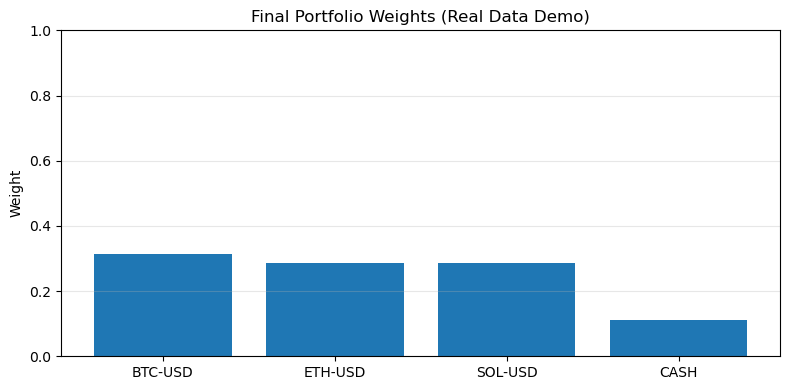

In [5]:
# Plot: real-data final allocation
w = pd.Series(portfolio_real.weights).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(w.index, w.values)
ax.set_title('Final Portfolio Weights (Real Data Demo)')
ax.set_ylabel('Weight')
ax.set_ylim(0, 1)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


## Conclusion

- The W8 portfolio decision layer is **rule-based** and explainable.
- Rules are deterministic and directly tied to user risk tolerance plus scenario risk metrics.
- This makes behavior auditable and stable for agent/API integration.
